In [13]:
import numpy as np
import pandas as pd
import os
import math
import re
import random
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score


In [14]:
#collect data - metadata
data = []
data_dir = "20_newsgroups"
classes = os.listdir(data_dir)
for folder in classes:
    folder_path = f"{data_dir}/{folder}"
    if(os.path.exists(folder_path)):
        files = os.listdir(folder_path)
        #print(len(files), folder_path)
        for file in files:
            file_path = f"{folder_path}/{file}"
            with open(file_path, "r", encoding="utf-8", errors="ignore" ) as f:
                text = f.read()
                data.append({"label": folder, "text": text})

In [15]:
## feature engineering - clean data
def clean_text(data):
    if not data:
        return []
    data = data.lower()
    data = re.sub(r'[^\w\s]', ' ', data)
    data = re.sub(r'\d+', ' ', data)
    data = re.sub(r'\s+', ' ', data).strip()
    token = data.split()
    token = [t for t in token if len(t) > 2]
    
    corpus_text = " ".join(token)
    return corpus_text, len(token)

#Count terms frequency for each document
def term_frequency(data):
    dictionary = dict.fromkeys(set(data), 0)
    for token in data:
        dictionary[token] +=1
    return dictionary

max_features = 0

for data_point in data:
    tokens, length = clean_text(data_point["text"])
    max_features = max(length, max_features)
    data_point["corpus_text"] = tokens

corpus = [dp["corpus_text"] for dp in data]
X = TfidfVectorizer(max_features=max_features, ngram_range=(1,2)).fit_transform(corpus)
y = [d["label"] for d in data]

In [16]:
model = LinearSVC(penalty='l2',dual="auto",multi_class="ovr",fit_intercept=True,max_iter=1000,verbose=True)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,stratify=y,shuffle=True)
model.fit(X_train,y_train)

[LibLinear]iter  1 act 1.134e+04 pre 1.134e+04 delta 8.727e-01 f 1.400e+04 |g| 2.598e+04 CG   1
cg reaches trust region boundary
iter  2 act 4.304e+02 pre 4.304e+02 delta 3.491e+00 f 2.659e+03 |g| 5.588e+02 CG   1
cg reaches trust region boundary
iter  3 act 9.354e+02 pre 9.010e+02 delta 4.314e+00 f 2.229e+03 |g| 7.082e+02 CG   2
cg reaches trust region boundary
iter  4 act 5.148e+02 pre 4.734e+02 delta 5.261e+00 f 1.293e+03 |g| 6.550e+02 CG   3
iter  5 act 2.211e+02 pre 1.952e+02 delta 5.534e+00 f 7.787e+02 |g| 5.615e+02 CG   4
iter  6 act 7.278e+01 pre 6.633e+01 delta 5.534e+00 f 5.576e+02 |g| 2.650e+02 CG   5
iter  7 act 5.584e+00 pre 4.833e+00 delta 5.534e+00 f 4.848e+02 |g| 1.364e+02 CG   2
iter  8 act 1.650e+01 pre 1.704e+01 delta 5.534e+00 f 4.792e+02 |g| 3.630e+01 CG   9
iter  9 act 8.631e-01 pre 8.618e-01 delta 5.534e+00 f 4.627e+02 |g| 1.559e+01 CG   7
iter 10 act 1.224e-01 pre 1.259e-01 delta 5.534e+00 f 4.619e+02 |g| 1.849e+00 CG  12
iter 11 act 3.112e-03 pre 3.113e-03 delt

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,True
,random_state,None


In [17]:
print(model.score(X_test,y_test))

0.9508333333333333


In [18]:
confusion_matrix = np.zeros((20,20),dtype=int)
total_accuracy = 0
for index, doc in enumerate(X_test):
    prediction = model.predict(doc)
    i = classes.index(prediction[0])
    j = classes.index(y_test[index]) 
    confusion_matrix[i][j] +=1
    if (y_test[index] == prediction):
        total_accuracy+=1

        
print("Accuracy: ",total_accuracy / X_test.shape[0])
y_pred = model.predict(X_test)

print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Micro F1:", f1_score(y_test, y_pred, average='micro'))

print("Macro Precision:", precision_score(y_test, y_pred, average='macro'))
print("Macro Recall:", recall_score(y_test, y_pred, average='macro'))

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy:  0.9508333333333333
Macro F1: 0.9507583005391634
Micro F1: 0.9508333333333333
Macro Precision: 0.9508851433175145
Macro Recall: 0.9508333333333333
Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.81      0.83      0.82       300
           comp.graphics       0.98      0.99      0.98       300
 comp.os.ms-windows.misc       0.99      0.98      0.98       300
comp.sys.ibm.pc.hardware       0.97      0.99      0.98       300
   comp.sys.mac.hardware       0.99      0.99      0.99       300
          comp.windows.x       0.99      0.98      0.98       300
            misc.forsale       0.98      0.98      0.98       300
               rec.autos       0.99      0.99      0.99       300
         rec.motorcycles       1.00      1.00      1.00       300
      rec.sport.baseball       1.00      1.00      1.00       300
        rec.sport.hockey       1.00      1.00      1.00       300
               sci.crypt  

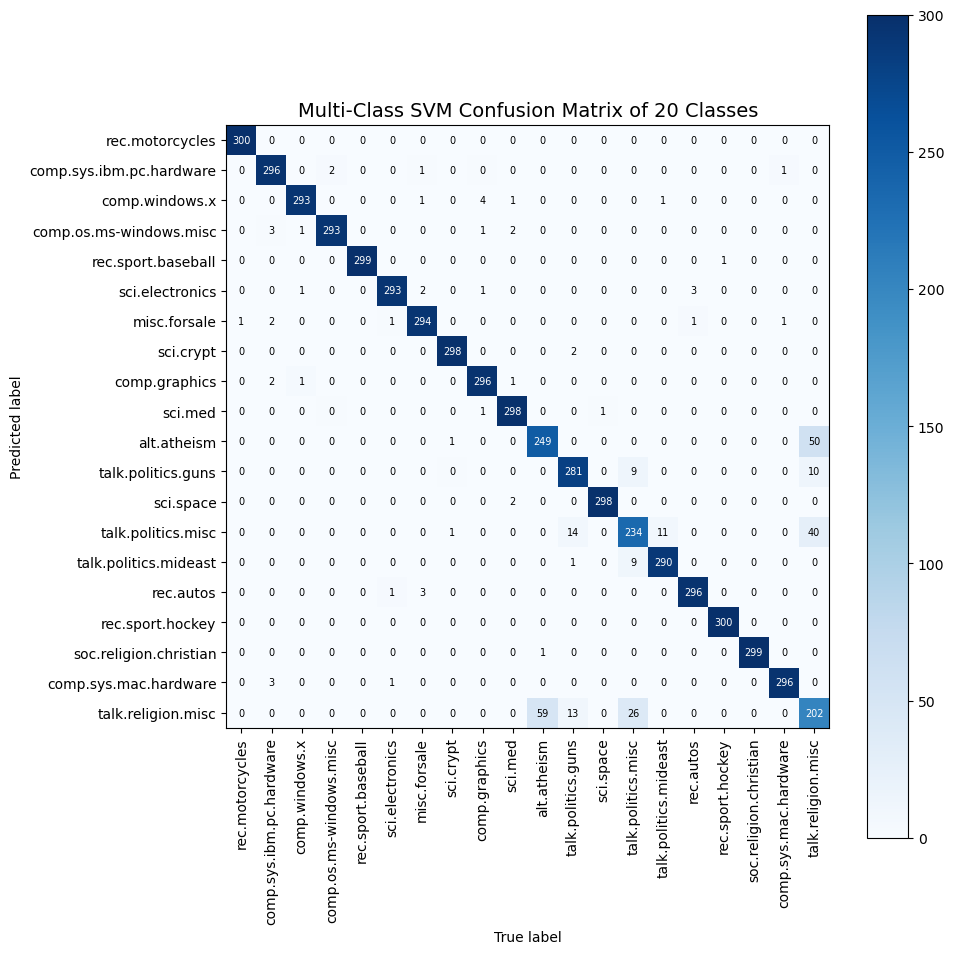

In [19]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(confusion_matrix, interpolation='nearest', cmap='Blues')

ax.set_title("Multi-Class SVM Confusion Matrix of 20 Classes", fontsize=14)
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=90)
ax.set_yticklabels(classes)

thresh = confusion_matrix.max() / 2.
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        ax.text(i, j, f"{confusion_matrix[i, j]:d}",
                ha="center", va="center",
                color="white" if confusion_matrix[i, j] > thresh else "black",
                fontsize=7)

ax.set_ylabel('Predicted label')
ax.set_xlabel('True label')
plt.tight_layout()
plt.show()